# 02. Atualizacao de figures/ e tables/

Roda depois de `01_demandas_revisores.ipynb` (secoes 05 a 17 ja executadas, com os CSVs e as figuras
datadas gravados em `analysis/resultados/`). Este notebook nao recalcula nada: le o que ja esta em
`resultados/` e faz duas coisas.

1. Arquiva o que ja existir em `jhpn_revisions/figures/` e `jhpn_revisions/tables/` num zip dentro de
   `_old/` de cada pasta, com timestamp. Nada e apagado sem backup, e o backup fica so dentro de `_old/`
   (nunca um `_bkp_` solto ao lado do arquivo atual).
2. Escreve a versao corrente: as 6 figuras finais (PNG 200dpi + PDF) em `figures/`, e as tabelas 1, 2 e 3
   formatadas em `.docx` (nao so CSV) em `tables/`.

A Figura 3 (PROBAST+AI, 17/08/2026) e feita a mao e nao existe em `resultados/`; o arquivamento preserva
o arquivo atual dela em `figures/` sem tocar.

## 01. Mount e caminhos

In [11]:
import os
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/USP/Doutorado/Coorte de pelotas/01_artigos/artigo_1'
    AMBIENTE = 'colab'
except ModuleNotFoundError:
    BASE = '../..'
    AMBIENTE = 'local'

OUT_DIR = f'{BASE}/jhpn_revisions/analysis/resultados'
FIGURAS = f'{BASE}/jhpn_revisions/Final_review/figures'
TABELAS = f'{BASE}/jhpn_revisions/Final_review/tables'
DATA = '20260826'          # rodada dos CSVs e das figuras 1, 2, 2b, S1 e S2
DATA_FIG4 = '20260831'     # Figura 4 refeita em 31/08 (dois paineis, presenca de preditor)
os.makedirs(FIGURAS, exist_ok=True)
os.makedirs(TABELAS, exist_ok=True)
print(AMBIENTE, '| BASE =', BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab | BASE = /content/drive/MyDrive/USP/Doutorado/Coorte de pelotas/01_artigos/artigo_1


In [12]:
%pip install -q python-docx
import shutil, zipfile, datetime
import pandas as pd
from docx import Document
from docx.shared import Pt, Cm
from docx.enum.section import WD_ORIENT

## 02. Arquivar o que ja existe

Zipa tudo que ja estiver hoje no primeiro nivel de `figures/` e de `tables/` (sem entrar em `_old/`) num
`.zip` unico por pasta, salvo em `<pasta>/_old/<pasta>_bkp_<timestamp>.zip`. Os arquivos que vao ser
sobrescritos pela secao seguinte sao removidos depois do zip gravado; o que nao vai ser regerado
(a Figura 3) fica preservado e fora da lista de remocao.

In [13]:
def arquivar_pasta(pasta, preservar=()):
    nome_pasta = os.path.basename(os.path.normpath(pasta))
    old_dir = f'{pasta}/_old'
    os.makedirs(old_dir, exist_ok=True)
    arquivos = [f for f in os.listdir(pasta)
                if os.path.isfile(f'{pasta}/{f}') and not f.startswith('.')]
    if not arquivos:
        print(f'{nome_pasta}/: nada para arquivar')
        return
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    zip_path = f'{old_dir}/{nome_pasta}_bkp_{ts}.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for f in arquivos:
            z.write(f'{pasta}/{f}', arcname=f)
    print(f'{nome_pasta}/_old/{os.path.basename(zip_path)}  ({len(arquivos)} arquivos)')
    removidos = [f for f in arquivos if f not in preservar]
    for f in removidos:
        os.remove(f'{pasta}/{f}')
    mantidos = set(arquivos) - set(removidos)
    if mantidos:
        print(f'  preservados em {nome_pasta}/ (nao regerados por este notebook): {sorted(mantidos)}')

FIG3 = {'fig3_probastai_20260817.png', 'fig3_probastai_20260817.pdf'}
arquivar_pasta(FIGURAS, preservar=FIG3)
arquivar_pasta(TABELAS)

figures/_old/figures_bkp_20260907_204727.zip  (14 arquivos)
  preservados em figures/ (nao regerados por este notebook): ['fig3_probastai_20260817.pdf', 'fig3_probastai_20260817.png']
tables/_old/tables_bkp_20260907_204727.zip  (3 arquivos)


## 03. Figura 4 refeita (31/08/2026)

A Figura 4 de 26/08 contava o campo `3 Most Important Features`, reportado em apenas 26 das 39
combinacoes, e media *importancia* declarada pelo estudo. A versao nova conta *presenca* do preditor
na lista de candidatos (`Predictor Types` do v7), disponivel nos 38 estudos, com o estudo como unidade,
e sai em dois paineis:

- **(A)** os 22 estudos em que ha antropometria da mesma dimensao do desfecho entre os preditores, que e
  o grupo que a versao submetida do manuscrito chamava de *data leakage* e que o texto revisado passou a
  chamar de tautologia diagnostica. O grupo vem da coluna `antropometria_preditores` de
  `leakage_recontado.csv`, gerada pela secao 09 do notebook 01.
- **(B)** os 37 estudos que contribuem com desfecho elegivel, ou seja, a prevalencia geral do preditor.

A canonizacao abaixo resolve as variantes de grafia dos artigos (`age in months`, `child age`, `usia`)
num nome unico, e descarta os rotulos de familia da extracao (`child`, `household`, `demographic`), que
sao agrupadores e nao preditores. Cobertura: 330 dos 436 itens que sao preditores de fato (76%); o que
sobra e cauda de item unico, sem efeito sobre os dez primeiros. As contagens vao para
`fig4_preditores_painelA.csv` e `fig4_preditores_painelB.csv`.

In [14]:
# -- 03.1 nova Figura 4: preditores candidatos mais presentes, em dois paineis --
# Substitui a versao de 26/08, que contava apenas o campo "3 Most Important Features"
# (top-3 reportado em 26 das 39 combinacoes). A versao nova conta PRESENCA do preditor
# na lista de candidatos ("Predictor Types" do v7), disponivel nos 38 estudos, e a
# unidade passa a ser o ESTUDO, nao a combinacao estudo x desfecho.
#   Painel A: os 22 estudos em que ha antropometria da mesma dimensao do desfecho
#             entre os preditores (o grupo que o manuscrito submetido chamava de leakage).
#   Painel B: os 37 estudos que contribuem com desfecho elegivel.
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

V7 = f'{BASE}/methods/extracao_artigo1_v7.xlsx'
VERM, AZUL, TINTA = '#C2453A', '#2A6FB0', '#222222'

# rotulos de familia da extracao (nao sao preditores)
STOP = re.compile(
    r'^(child|maternal|paternal|parental|household|family|demographic|sociodemographic|'
    r'socio-?economic|socioeconomic|geographic|anthropometric|child anthropometric|'
    r'child demographic|child sociodemographic|child characteristics|child morbidity|'
    r'clinical|behavioural|behavioral|dietary|environmental|nutritional|wash|household/wash|'
    r'child anthropometric/demographic|household/socioeconomic|others?|other variables?|'
    r'variables?|predictors?|nr|na|not reported|none|z-score|categories|etc)$')

CANONICO = [
    (r'^(child\s+)?(age at measurement|age in months|age \(months\)|age)$|child.*\bage\b|\bage in months\b', 'Child age'),
    (r'\bsex\b|gender', 'Child sex'),
    (r'weight[-/ ]for[-/ ](height|length)|\bwhz\b|\bw\s*/\s*h\b', 'Weight-for-height'),
    (r'weight[-/ ]for[-/ ]age|\bwaz\b|\bw\s*/\s*a\b|^weight/age$', 'Weight-for-age'),
    (r'height[-/ ]for[-/ ]age|\bhaz\b|\bh\s*/\s*a\b|tb\s*/\s*u', 'Height-for-age'),
    (r'birth\s*_?\s*(weight|wt)|weight at birth', 'Birth weight'),
    (r'birth\s*_?\s*(length|height|size)|size at birth', 'Birth length or size'),
    (r'(mid[- ]?)?upper[- ]?arm circumference|\bmuac\b|\blila\b|lingkar lengan', 'MUAC'),
    (r'head circumference', 'Head circumference'),
    (r'\bbmi\b|body mass|\bimc\b|\bzbmi\b|\bbaz\b', 'Body mass index'),
    (r'^(child\s+)?(height|length|stature)\b|height in cm|child.*(height|length)', 'Height or length'),
    (r'^(child\s+)?weight\b|child.*weight|weight in kg', 'Weight'),
    (r"(maternal|mother'?s?)\s*(bmi|body mass)", 'Maternal BMI'),
    (r"(maternal|mother'?s?)\s*(height|stature)", 'Maternal height'),
    (r"(maternal|mother'?s?)\s*educ|mother.*schooling", 'Maternal education'),
    (r"(paternal|father'?s?|partner)\s*educ", 'Paternal education'),
    (r"(maternal|mother'?s?)\s*age|age of mother", 'Maternal age'),
    (r"(maternal|mother'?s?|paternal|father'?s?)\s*(occupation|employ|work)", 'Parental occupation'),
    (r'^education$|educational (level|attainment)|schooling|couple education|'
     r'education of mother|^couple$|^partner$', 'Parental education'),
    (r'antenatal|prenatal (care|visit)', 'Antenatal care'),
    (r'place of delivery|delivery place|delivery mode|mode of delivery|caesar|cesar|'
     r"place of (child'?s? )?birth", 'Delivery'),
    (r'birth order|birth rank|parity', 'Birth order or parity'),
    (r'birth interval|preceding interval', 'Birth interval'),
    (r'twin|multiple birth', 'Twin status'),
    (r'gestational age|preterm|premature', 'Gestational age'),
    (r'breast\s*-?\s*feed|breastfeeding|exclusive breast', 'Breastfeeding'),
    (r'complementary feeding|weaning|dietary diversity|food (intake|consumption|frequency)|'
     r'diet\b|meal|nutrition intake', 'Diet and feeding'),
    (r'fast[- ]?food', 'Fast-food intake'),
    (r'vitamin|supplement|micronutrient|iron|zinc|deworm', 'Micronutrient supplementation'),
    (r'immuni[sz]|vaccin', 'Immunisation'),
    (r'wealth|asset index|\bincome\b|poverty|economic status', 'Household wealth or income'),
    (r'household size|family size|number of (children|household|siblings)|sibling', 'Household size'),
    (r'toilet|sanitation|latrine', 'Sanitation'),
    (r'(drinking )?water(\s+(source|supply))?$|water source', 'Water source'),
    (r'\bregion\b|province|district|state\b|geographic', 'Region'),
    (r'residen|urban|rural', 'Place of residence'),
    (r'television|\btv\b|radio|refrigerator|motorcycle|electricity|asset ownership', 'Household assets'),
    (r'floor|roof|wall|housing|dwelling|room', 'Housing conditions'),
    (r'ethnic|race|caste|religion', 'Ethnicity or religion'),
    (r'health insurance|insurance', 'Health insurance'),
    (r'marital|married', 'Marital status'),
    (r'^(occupation|employment|work status)$', 'Occupation'),
    (r'diarrh', 'Diarrhoea'),
    (r'fever\b', 'Fever'),
    (r'cough|ari\b|respiratory infection', 'Respiratory symptoms'),
    (r'anaemi|anemi|h(a)?emoglobin', 'Anaemia'),
    (r'physical activity|exercise|sedentary|screen time|sleep', 'Physical activity or sleep'),
    (r'smok|tobacco|alcohol', 'Smoking or alcohol'),
]
ANTRO_DESF = {'Height or length', 'Weight', 'Body mass index', 'Height-for-age',
              'Weight-for-age', 'Weight-for-height'}


def itens_pred(txt):
    t = str(txt)
    if t.strip().lower() in ('nan', 'nr', ''):
        return []
    t = re.sub(r'\(([^)]*)\)', r', \1', t)   # o que esta entre parenteses tambem e item
    return [p.strip(' .') for p in re.split(r'[;,]| and (?=[a-z])', t) if len(p.strip(' .')) > 1]


def canoniza_pred(txt):
    t = re.sub(r'\s+', ' ', str(txt).strip().lower().strip(' .:-'))
    if not t or STOP.match(t):
        return None
    for padrao, nome in CANONICO:
        if re.search(padrao, t):
            return nome
    return None


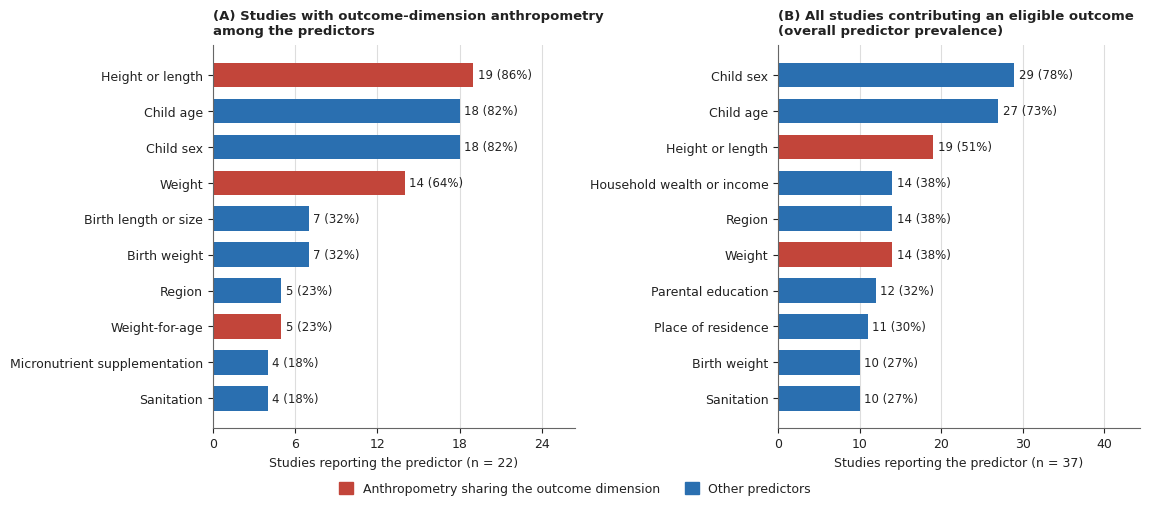

resultados/fig4_preditores_20260831.png/.pdf | A: 22 estudos | B: 37 estudos
                     preditor  estudos  pct  antro_desfecho
             Height or length       19   86            True
                    Child age       18   82           False
                    Child sex       18   82           False
                       Weight       14   64            True
         Birth length or size        7   32           False
                 Birth weight        7   32           False
                       Region        5   23           False
               Weight-for-age        5   23            True
Micronutrient supplementation        4   18           False
                   Sanitation        4   18           False


In [15]:
# -- 03.2 contagem e desenho --
lk = pd.read_csv(f'{OUT_DIR}/leakage_recontado.csv', sep=';', encoding='utf-8-sig')
ids_todos = sorted(lk['ID'].unique())
ids_antro = sorted(lk[lk['antropometria_preditores']]['ID'].unique())

v7 = pd.read_excel(V7, sheet_name='Per Combination', header=1)
# AA_10 (Kar, 2021) modelou apenas um desfecho composto de desnutricao, sem dimensao
# antropometrica isolavel. E inelegivel, e sai de todas as contagens.
EXCLUIDOS = ['AA_10']
v7 = v7[~v7['ID'].isin(EXCLUIDOS)].copy()
v7 = v7[v7['ID'].notna()].drop_duplicates(subset=['ID']).set_index('ID')


def conta_presenca(ids):
    linhas = []
    for i in ids:
        nomes = {canoniza_pred(x) for x in itens_pred(v7.loc[i, 'Predictor Types'])}
        nomes.discard(None)
        linhas += [{'ID': i, 'preditor': n} for n in nomes]
    c = (pd.DataFrame(linhas).groupby('preditor')['ID'].nunique().rename('estudos')
         .sort_values(ascending=False).reset_index())
    c['pct'] = (100 * c['estudos'] / len(ids)).round(0).astype(int)
    c['antro_desfecho'] = c['preditor'].isin(ANTRO_DESF)
    return c


A, B = conta_presenca(ids_antro), conta_presenca(ids_todos)
A.to_csv(f'{OUT_DIR}/fig4_preditores_painelA.csv', sep=';', index=False, encoding='utf-8-sig')
B.to_csv(f'{OUT_DIR}/fig4_preditores_painelB.csv', sep=';', index=False, encoding='utf-8-sig')

plt.rcParams.update({'font.family': 'DejaVu Sans', 'text.color': TINTA,
                     'axes.labelcolor': TINTA, 'xtick.color': TINTA, 'ytick.color': TINTA,
                     'axes.edgecolor': '#666666', 'savefig.dpi': 200})
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.9))
for ax, cont, n, letra, tit in [
        (axes[0], A, len(ids_antro), 'A',
         'Studies with outcome-dimension anthropometry\namong the predictors'),
        (axes[1], B, len(ids_todos), 'B',
         'All studies contributing an eligible outcome\n(overall predictor prevalence)')]:
    top = cont.head(10).iloc[::-1]
    barras = ax.barh(top['preditor'], top['estudos'],
                     color=[VERM if a else AZUL for a in top['antro_desfecho']], height=0.68)
    for b, e, p in zip(barras, top['estudos'], top['pct']):
        ax.text(b.get_width() + n * 0.015, b.get_y() + b.get_height() / 2,
                f'{e} ({p}%)', va='center', fontsize=8.5, color=TINTA)
    ax.set_xlim(0, n * 1.20)
    ax.set_xlabel(f'Studies reporting the predictor (n = {n})', fontsize=9)
    ax.set_title(f'({letra}) {tit}', fontsize=9.5, fontweight='bold', loc='left', pad=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))
    ax.tick_params(labelsize=9)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color='#DDDDDD')
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
mp = [plt.Rectangle((0, 0), 1, 1, color=VERM), plt.Rectangle((0, 0), 1, 1, color=AZUL)]
fig.legend(mp, ['Anthropometry sharing the outcome dimension', 'Other predictors'],
           loc='lower center', ncol=2, frameon=False, fontsize=9,
           handlelength=1.1, handleheight=1.1, bbox_to_anchor=(0.5, -0.045))
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(f'{OUT_DIR}/fig4_preditores_{DATA_FIG4}.{ext}', bbox_inches='tight')
plt.show()
print(f'resultados/fig4_preditores_{DATA_FIG4}.png/.pdf | A: {len(ids_antro)} estudos | '
      f'B: {len(ids_todos)} estudos')
print(A.head(10).to_string(index=False))


## 04. Figuras finais (copia de `resultados/` com o carimbo de data corrente)

Mesma logica da secao 16 do `01_demandas_revisores.ipynb`. A Figura 4 vem da secao 03
acima, com carimbo de data proprio (`DATA_FIG4`).

In [16]:
# fig2b (mapa avulso) entrou em 30/08; a Figura 4 tem data propria porque foi refeita depois
FINAIS = {'fig1_prisma': DATA, 'fig2_distribuicao': DATA, 'fig2b_mapa': DATA,
          'fig4_preditores': DATA_FIG4, 'figS1_auc_desfecho': DATA, 'figS2_desempenho_preditor': DATA}
for nome, data_fig in FINAIS.items():
    for ext in ('png', 'pdf'):
        arq = f'{OUT_DIR}/{nome}_{data_fig}.{ext}'
        if os.path.exists(arq):
            shutil.copy2(arq, f'{FIGURAS}/{nome}_{data_fig}.{ext}')
            print(f'figures/{nome}_{data_fig}.{ext}')
        else:
            print(f'AUSENTE em resultados/: {nome}_{data_fig}.{ext}')
print('mantida sem alteracao: fig3_probastai_20260817.png/.pdf')

figures/fig1_prisma_20260826.png
figures/fig1_prisma_20260826.pdf
figures/fig2_distribuicao_20260826.png
figures/fig2_distribuicao_20260826.pdf
figures/fig2b_mapa_20260826.png
figures/fig2b_mapa_20260826.pdf
figures/fig4_preditores_20260831.png
figures/fig4_preditores_20260831.pdf
figures/figS1_auc_desfecho_20260826.png
figures/figS1_auc_desfecho_20260826.pdf
figures/figS2_desempenho_preditor_20260826.png
figures/figS2_desempenho_preditor_20260826.pdf
mantida sem alteracao: fig3_probastai_20260817.png/.pdf


## 05. Tabelas formatadas (.docx) em `tables/`

Table 1 (estudos), Table 2 (desempenho por desfecho) e Table 3 (certeza da evidencia, GRADE), a partir dos
CSVs que a secao 17 do notebook 01 ja grava em `resultados/`. Fonte Calibri, `Table Grid`, cabecalho em
negrito; Table 1 sai em paisagem por ter 11 colunas.

In [17]:
def novo(paisagem=False):
    d = Document()
    st = d.styles['Normal']; st.font.name = 'Calibri'; st.font.size = Pt(10)
    s = d.sections[0]
    s.left_margin = s.right_margin = Cm(1.5)
    if paisagem:
        s.orientation = WD_ORIENT.LANDSCAPE
        s.page_width, s.page_height = s.page_height, s.page_width
    return d

def titulo(d, txt):
    p = d.add_paragraph(); r = p.add_run(txt)
    r.font.size = Pt(12); r.bold = True
    p.paragraph_format.space_after = Pt(8)

def tabela(d, header, rows, fonte=8):
    t = d.add_table(rows=1, cols=len(header)); t.style = 'Table Grid'
    for c, h in zip(t.rows[0].cells, header):
        c.text = ''
        r = c.paragraphs[0].add_run(str(h)); r.bold = True; r.font.size = Pt(fonte)
    for row in rows:
        cells_ = t.add_row().cells
        for c, v in zip(cells_, row):
            c.text = ''
            r = c.paragraphs[0].add_run('' if pd.isna(v) else str(v)); r.font.size = Pt(fonte)
    return t

def ler(nome):
    return pd.read_csv(f'{OUT_DIR}/{nome}', sep=';', encoding='utf-8-sig')

In [18]:
t1 = ler('table1_estudos.csv')
d = novo(paisagem=True)
titulo(d, 'Table 1. Characteristics and performance of the 39 eligible study-outcome combinations')
tabela(d, t1.columns.tolist(), t1.values.tolist(), fonte=7)
d.save(f'{TABELAS}/table1_estudos.docx')
print('tables/table1_estudos.docx', t1.shape)

tables/table1_estudos.docx (39, 11)


In [19]:
t2 = ler('table2_desempenho.csv')
d = novo()
titulo(d, 'Table 2. Model performance and heterogeneity by nutritional outcome')
tabela(d, t2.columns.tolist(), t2.values.tolist(), fonte=8)
d.save(f'{TABELAS}/table2_desempenho.docx')
print('tables/table2_desempenho.docx', t2.shape)

tables/table2_desempenho.docx (4, 9)


In [20]:
t3 = ler('table3_grade.csv')
d = novo()
titulo(d, 'Table 3. Certainty of the evidence by nutritional outcome (adapted GRADE)')
tabela(d, t3.columns.tolist(), t3.values.tolist(), fonte=9)
d.save(f'{TABELAS}/table3_grade.docx')
print('tables/table3_grade.docx', t3.shape)

tables/table3_grade.docx (4, 8)


## 06. Proximo passo

1. Conferir `figures/` e `tables/` (abrir os `.docx` para checar quebras de linha e largura de coluna).
2. Se algo estiver errado, os arquivos anteriores estao no zip em `figures/_old/` e `tables/_old/`; nao
   precisa rerodar o notebook 01 so por causa disso.
3. Rodar de novo sempre que o notebook 01 gerar uma nova rodada de `resultados/` (mudar a constante `DATA`
   acima para a data da rodada nova antes de rodar).